In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

In [40]:
soy_raw = pd.read_csv('soy_raw.csv')
sm = pd.read_csv('sm.csv')
vod = pd.read_csv('vod.csv')

In [41]:
soy_raw.insert(5, column='tmax_avg', value=soy_raw.iloc[:,1:5].agg('mean', axis=1))
soy_raw.insert(10, column='prcp_avg', value=soy_raw.iloc[:,6:9].agg('mean', axis=1))
soy_raw.head()

,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,tmax_avg,prcp_apr,prcp_may,prcp_jun,prcp_jul,prcp_avg
0,4.194062,26.944885,31.191715,33.047821,34.505318,31.422435,197.227264,133.386368,137.943176,186.301132,156.185603
1,7.157392,19.691486,23.379566,27.378342,28.906879,24.839068,64.965958,128.230209,273.581238,253.794022,155.592468
2,9.170855,16.248007,21.388821,25.129047,27.099064,22.466235,81.545547,136.449112,167.224213,122.737778,128.406291
3,7.172860,19.613501,23.488871,27.322500,28.711775,24.784162,59.570000,123.529999,280.100006,241.889999,154.400002
4,9.197968,17.863222,22.617496,26.069649,27.146734,23.424275,89.199593,138.738678,218.345963,111.989548,148.761411


In [42]:
temp_cols = ["tmax_apr", "tmax_may", "tmax_jun", "tmax_jul"]
X = soy_raw[temp_cols].values
y = soy_raw["yield"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pls = PLSRegression(n_components=1)
pls.fit(X_scaled, y)

weights = pls.x_weights_[:, 0]
for c, w in zip(temp_cols, weights):
    print(f"{c}: {w:+.3f}")

soy_raw["temp_pls"] = pls.transform(X_scaled)[:, 0]

tmax_apr: +0.436
tmax_may: +0.335
tmax_jun: +0.380
tmax_jul: +0.744


In [43]:
# Process the daily soil moisture and VOD data into a 4-month mean, 90th percentile, and 10th percentile.

sm_data = pd.DataFrame({
    'sm_mean': sm.mean(axis=1),
    'sm_q5': sm.quantile(0.05, axis=1),
    'sm_q95': sm.quantile(0.95, axis=1),
    'sm_std': sm.std(axis=1)
})

vod_data = pd.DataFrame({
    'vod_mean': vod.mean(axis=1),
    'vod_q5': vod.quantile(0.05,axis=1),
    'vod_q95': vod.quantile(0.95,axis=1),
    'vod_std': vod.std(axis=1)
})

sm_data.head()

,sm_mean,sm_q5,sm_q95,sm_std
0,0.160216,0.091869,0.238131,0.044583
1,0.197299,0.138234,0.236725,0.032614
2,0.172573,0.073943,0.233433,0.045325
3,0.220197,0.152329,0.265495,0.035747
4,0.179592,0.063475,0.265588,0.055550


In [44]:
# Combine all values into one final dataframe

soy_data = pd.concat([soy_raw, sm_data, vod_data],axis=1)
soy_data.head()

,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,tmax_avg,prcp_apr,prcp_may,prcp_jun,prcp_jul,prcp_avg,temp_pls,sm_mean,sm_q5,sm_q95,sm_std,vod_mean,vod_q5,vod_q95,vod_std
0,4.194062,26.944885,31.191715,33.047821,34.505318,31.422435,197.227264,133.386368,137.943176,186.301132,156.185603,4.763236,0.160216,0.091869,0.238131,0.044583,0.393141,0.316100,0.494518,0.054919
1,7.157392,19.691486,23.379566,27.378342,28.906879,24.839068,64.965958,128.230209,273.581238,253.794022,155.592468,-0.000780,0.197299,0.138234,0.236725,0.032614,0.279009,0.225902,0.321308,0.032779
2,9.170855,16.248007,21.388821,25.129047,27.099064,22.466235,81.545547,136.449112,167.224213,122.737778,128.406291,-1.667232,0.172573,0.073943,0.233433,0.045325,0.227040,0.167861,0.288062,0.038181
3,7.172860,19.613501,23.488871,27.322500,28.711775,24.784162,59.570000,123.529999,280.100006,241.889999,154.400002,-0.081674,0.220197,0.152329,0.265495,0.035747,0.317403,0.262077,0.391281,0.038965
4,9.197968,17.863222,22.617496,26.069649,27.146734,23.424275,89.199593,138.738678,218.345963,111.989548,148.761411,-1.181285,0.179592,0.063475,0.265588,0.055550,0.206323,0.136790,0.282111,0.047684


             yield  tmax_apr  tmax_may  tmax_jun  tmax_jul  tmax_avg  \
yield     1.000000 -0.232890 -0.178892 -0.202703 -0.397152 -0.299176   
tmax_apr -0.232890  1.000000  0.186171  0.594463  0.680873  0.809595   
tmax_may -0.178892  0.186171  1.000000  0.594091  0.540345  0.672879   
tmax_jun -0.202703  0.594463  0.594091  1.000000  0.843095  0.887744   
tmax_jul -0.397152  0.680873  0.540345  0.843095  1.000000  0.905833   
tmax_avg -0.299176  0.809595  0.672879  0.887744  0.905833  1.000000   
prcp_apr -0.084017  0.615493  0.168225  0.425488  0.484023  0.543966   
prcp_may -0.084287  0.426482  0.000626  0.223033  0.228956  0.298943   
prcp_jun  0.099040 -0.112478  0.237350 -0.252288 -0.260346 -0.088383   
prcp_jul  0.142160  0.253168 -0.115814  0.039150 -0.140786  0.058294   
prcp_avg -0.013964  0.424978  0.242971  0.146314  0.173214  0.348537   
temp_pls -0.331764  0.764768  0.648579  0.910433  0.958173  0.987664   
sm_mean  -0.092437  0.193035  0.009378  0.025518  0.082113  0.11

<Axes: >

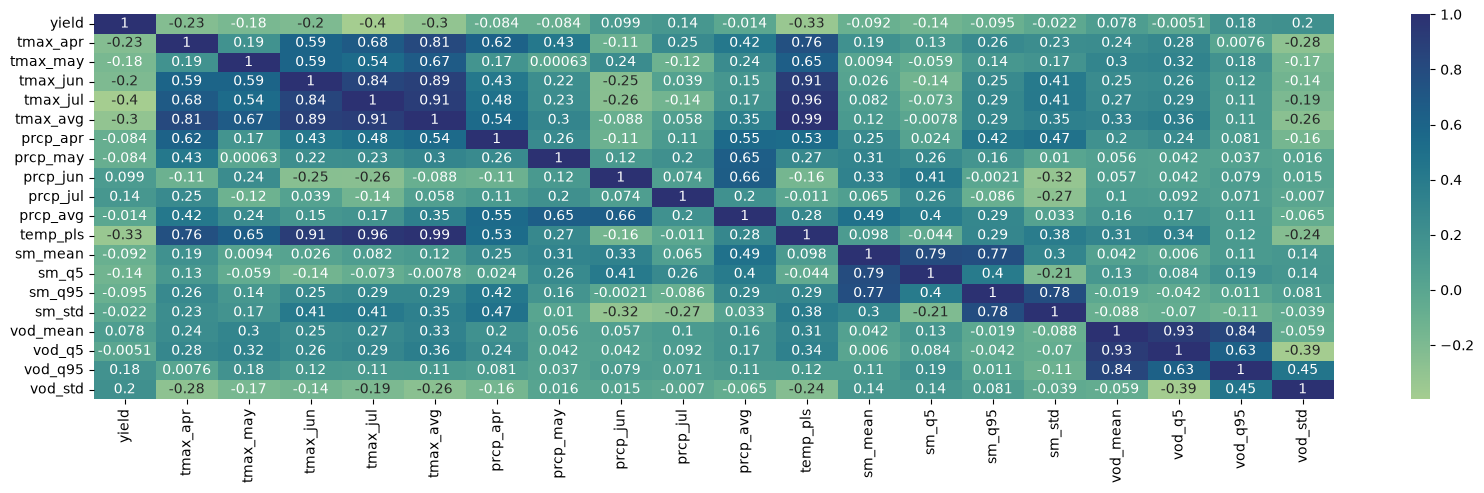

In [45]:
# jj

fig,axes = plt.subplots(1,1,figsize=(20,5))
soy_corr_mat = soy_data.corr(numeric_only=True)
print(soy_corr_mat)
sb.heatmap(soy_corr_mat, annot=True, cmap='crest', ax=axes)

                  yield  tmax_apr  tmax_may  tmax_jun  tmax_jul  tmax_avg  \
yield          1.000000 -0.232890 -0.178892 -0.202703 -0.397152 -0.299176   
tmax_apr      -0.232890  1.000000  0.186171  0.594463  0.680873  0.809595   
tmax_may      -0.178892  0.186171  1.000000  0.594091  0.540345  0.672879   
tmax_jun      -0.202703  0.594463  0.594091  1.000000  0.843095  0.887744   
tmax_jul      -0.397152  0.680873  0.540345  0.843095  1.000000  0.905833   
tmax_avg      -0.299176  0.809595  0.672879  0.887744  0.905833  1.000000   
prcp_apr      -0.084017  0.615493  0.168225  0.425488  0.484023  0.543966   
prcp_may      -0.084287  0.426482  0.000626  0.223033  0.228956  0.298943   
prcp_jun       0.099040 -0.112478  0.237350 -0.252288 -0.260346 -0.088383   
prcp_jul       0.142160  0.253168 -0.115814  0.039150 -0.140786  0.058294   
prcp_avg      -0.013964  0.424978  0.242971  0.146314  0.173214  0.348537   
temp_pls      -0.331764  0.764768  0.648579  0.910433  0.958173  0.987664   

<Axes: >

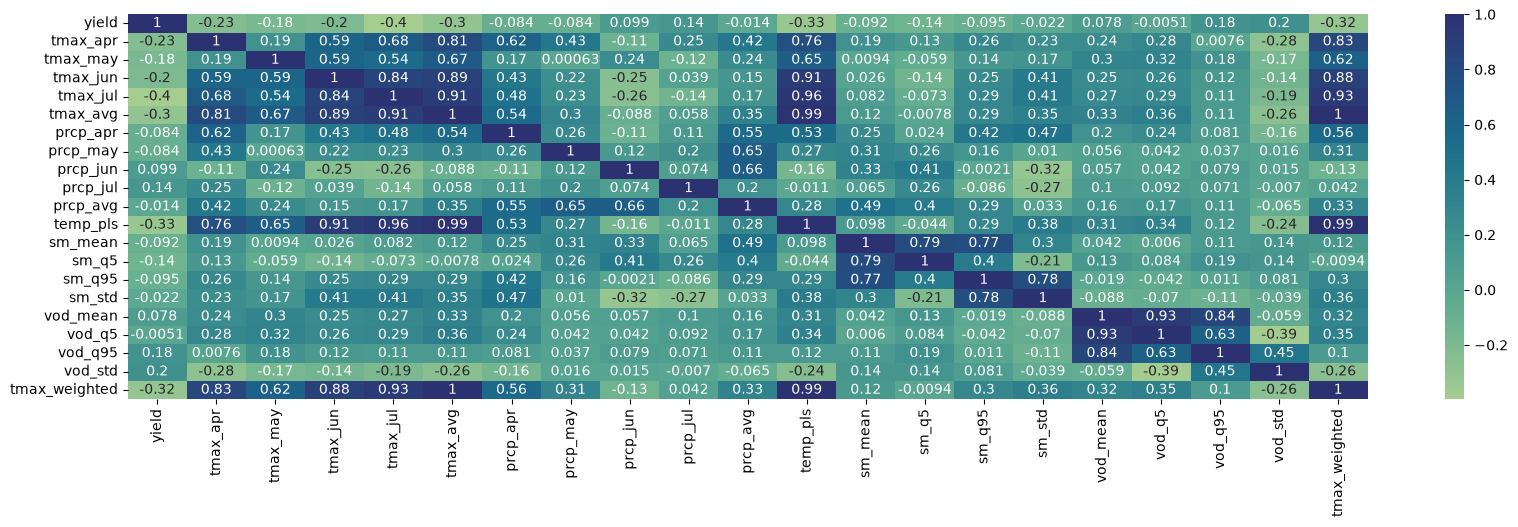

In [46]:
# Weighted average of tmax_{month} columns, weighted by each column's correlation with yield

tmax_cols = ['tmax_apr', 'tmax_may', 'tmax_jun', 'tmax_jul']
tmax_weights = soy_data[tmax_cols].corrwith(soy_data['yield'])
soy_data['tmax_weighted'] = soy_data[tmax_cols].mul(tmax_weights).sum(axis=1) / tmax_weights.sum()

fig, axes = plt.subplots(1, 1, figsize=(20, 5))
soy_corr_mat_2 = soy_data.corr(numeric_only=True)
print(soy_corr_mat_2)
sb.heatmap(soy_corr_mat_2, annot=True, cmap='crest', ax=axes)